# Módelo Churn

## Descripción

- **Marco Teórico**:
  - Churn: pérdida de clientes. En ecommerce un cliente churned. Tasa de abandono. 
  - Modelo churn: sistema que predice que identifica qué clientes tienen mayor probabilidad de abandonar un servicio en x tiempo a futuro. En este caso dejar de hacer compras.
  - Modelos de regresión: predicen un valor. Ej: 
  - Modelos de clasificación: predicen la pertencencia o clasificación a un clase definida. Ej: De los clientes, ¿quiénes son más propensos una COMPRA, ABANDONO, etc?

- **Problema**: 
Normalmente las campañas 

- **Objetivo**:
  - Predecir qué cliente 
  - Brindar información relevante y clave que pueda servir para implementar óptimas estrategias de marketing y fidelización.
  - Reducir costos o pérdida de ingresos.
  
- **Planteamiento**:
  - Realizar EDA, para encontrar qué variables permiten predecir con mejor taza.
  - Realizar 3 modelos: Regresión Lineal, Random Forest, Árbol de regresión
  - Compararar entre modelos y escoger el mejor.
  


## Consideraciones
- Como Modelo Churn aplica sobre los clientes que han realizado al menos una compra, entonces la data se filtra solo para clientes con al menos 1 compra.
- Necesitamos datos históricos de compra y clientes, así como actuales. Usaremos orders y customers a través de 'id_cliente' para su unión.
- Resultado esperado: 0(si compra en el umbral definido) y 1(no compra)
- Umbral definido: a evaluar. Ej: los ultimos 30 días
- Análisis realizado para el 24 de Septiembre, esta información varia en el tiempo.

# Obtención datos

In [ ]:
import sys, os
from supabase import create_client, Client
from dotenv import load_dotenv
import pandas as pd
from tqdm import tqdm
import numpy as np
import seaborn as sns
# import plotly.express as px
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('..'))

from etl.extract import extract_supabase

load_dotenv()
url= os.environ.get("SUPABASE_URL")
key= os.environ.get("SUPABASE_KEY")
supabase: Client = create_client(url, key)

endpoints= [ "products","customers","orders","orders_products"]
esquema='clean'
df_clean= {}
for endpoint in tqdm(endpoints):
    df_clean[f'{endpoint}_clean']= extract_supabase(supabase=supabase,endpoint=endpoint, esquema=esquema)


 25%|██▌       | 1/4 [00:04<00:13,  4.50s/it]

[OK]  Extracción correcta realizada para products_clean
Filas: 1366



 50%|█████     | 2/4 [00:06<00:05,  2.76s/it]

[OK]  Extracción correcta realizada para customers_clean
Filas: 1875



 75%|███████▌  | 3/4 [00:08<00:02,  2.82s/it]

[OK]  Extracción correcta realizada para orders_clean
Filas: 2406



100%|██████████| 4/4 [00:09<00:00,  2.49s/it]

[OK]  Extracción correcta realizada para orders_products_clean
Filas: 3060



In [2]:
df_clean.keys()
customers= df_clean['customers_clean']
orders= df_clean['orders_clean']

# EDA

**Objetivo**
Entender el comportamiento de compra.

### Distribución de número de compras por cliente
¿La mayoría compra 1 vez o hay repetidores?

### Análisis inicial
Crear una columna en customers: nro_compras (0,1,2...)
1. Verificar si la cantidad de valores unicos de id_clientes en orders, coincide con la cantidad de id en customers
2.  Unir orders con customers por id_cliente
2. Verificar si 

In [3]:
totalC= customers['id_cliente'].nunique()
clientes_ordenes= orders['id_cliente'].nunique()
ventas= orders[orders['estado_orden']=='Pagada']
clientes_compras= ventas['id_cliente'].nunique()

print(f'Clientes totales: {totalC}')
print(f'CLientes con órdenes: {clientes_ordenes}')
print(f'Clientes con ninguna orden:{totalC-clientes_ordenes}')
print(f'Compras(ventas) totales: {len(ventas)}')
print(f'Clientes que han realizado compras: {clientes_compras}')
print(f'Clientes que NO han realizado compras: {totalC-clientes_compras}')

Clientes totales: 1875
CLientes con órdenes: 822
Clientes con ninguna orden:1053
Compras(ventas) totales: 712
Clientes que han realizado compras: 584
Clientes que NO han realizado compras: 1291


El nuevo df solo contará con los **584** clientes que sí han comprado.

### **Distribucion de compra**,  frecuencia de clientes que compra 0,1,2...
1. Para la unión de clientes con ventas, realizar la unión 'right'. Porque Devuelve los registros de *customers* que sí tengan ventas(NECESARIO filtrar para el modelo):
2. Agrupamos por id_cliente y contamos los id_orden. Y ordenamos por cantidad de compras. 
3. Renombramos columnas.
4. Agrupamos por nro de compras, para obtener la cantidad de clientes que realiza 1,2...n compras.
5. Generamos la cantidad porcentual de la cantidad de clientes.


In [47]:
clientes_ventas.columns

Index(['id_cliente', 'acepta_marketing', 'id_orden', 'fecha_creacion',
       'precio_total', 'estado_cumplimiento', 'estado_orden', 'estado_envio',
       'estado_cliente'],
      dtype='object')

In [4]:
clientes_ventas= pd.merge(customers, ventas, on='id_cliente', how='right')
clientes_ventas=clientes_ventas[['id_cliente', 'acepta_marketing','id_orden',
       'fecha_creacion', 'precio_total', 'estado_cumplimiento',
       'estado_orden', 'estado_envio', 'estado_cliente']]
# precio a 0 para los que nunca han comprado
# clientes_ventas['precio_total']= clientes_ventas['precio_total'].apply(lambda x: 0 if pd.isna(x) else x)

compras_cliente= clientes_ventas.groupby('id_cliente')['id_orden'].count().reset_index().sort_values('id_orden', ascending=False)  
# Frecuency
compras_cliente.columns=['id_cliente','nro_compras'] #renombra 

distribucion= compras_cliente.groupby('nro_compras')['id_cliente'].count().reset_index()
distribucion.columns=['nro_compras','nro_clientes']

# total de clientes == distribucion['id_cliente'].sum() o variable ya definida 'totalC'
distribucion['porcentaje_cliente']= distribucion['nro_clientes'].apply(lambda x: round(x/totalC*100,2) )
distribucion

,nro_compras,nro_clientes,porcentaje_cliente
0,1,541,28.85
1,2,33,1.76
2,3,6,0.32
3,5,2,0.11
4,20,1,0.05
5,57,1,0.05


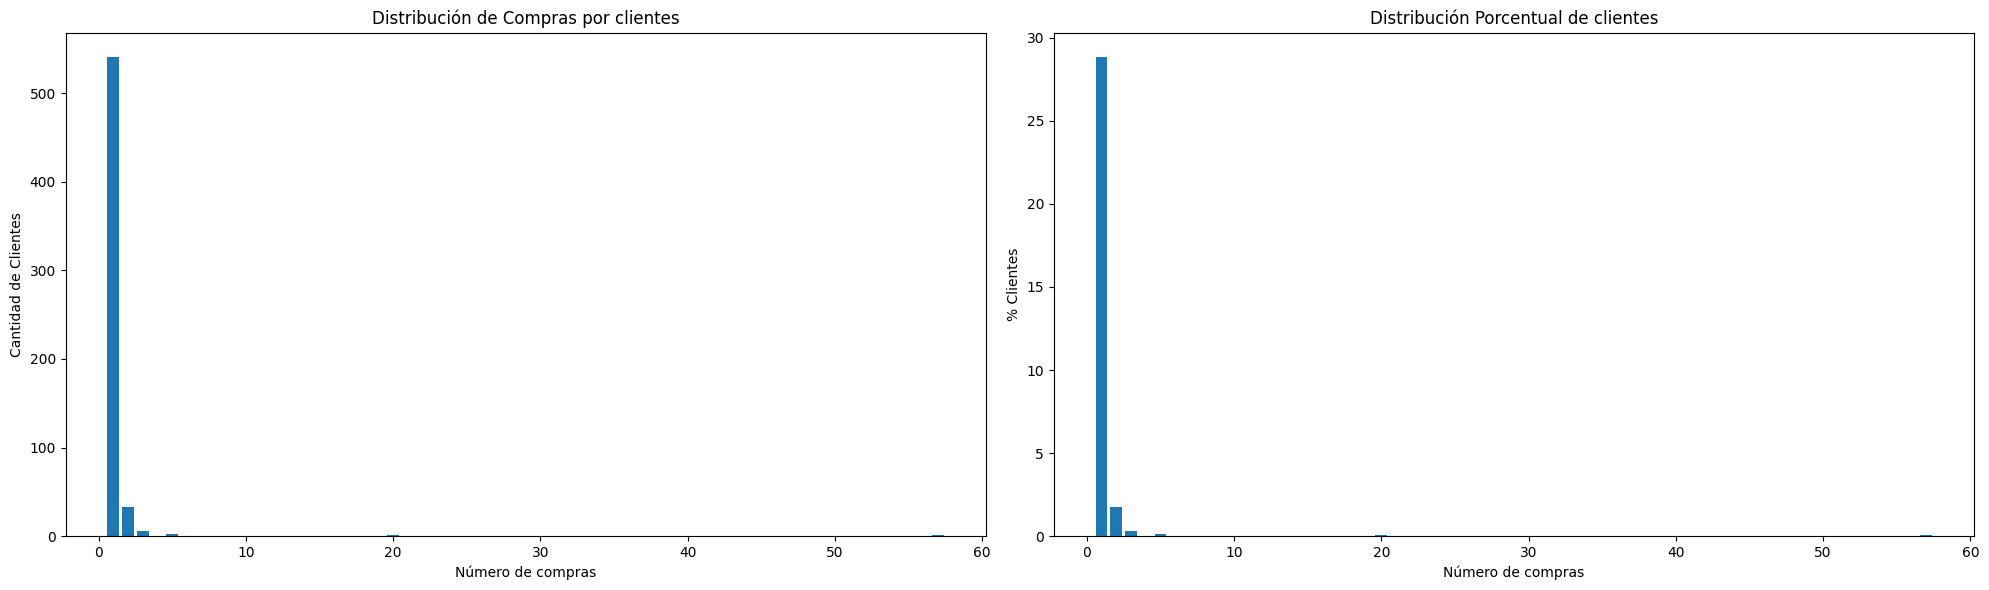

In [5]:
# grafica
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))


axes[0].bar(distribucion['nro_compras'], distribucion['nro_clientes'])
axes[0].set_title('Distribución de Compras por clientes')
axes[0].set_xlabel('Número de compras')
axes[0].set_ylabel('Cantidad de Clientes')

axes[1].bar(distribucion['nro_compras'], distribucion['porcentaje_cliente'])
axes[1].set_title('Distribución Porcentual de clientes')
axes[1].set_xlabel('Número de compras')
axes[1].set_ylabel('% Clientes')

plt.tight_layout()
plt.show()


**Conclusión**
- Existen outliers: 1 comprador con 57 compras.
- La distribución se encuentra sesgada hacia la derecha, lo que implica que la gran mayoria de clientes han realizado compras menores a 5.

In [6]:
# OJo: 
# Alerta: Hay 5 órdenes que han sido registradas como Pagada pero el monto es de cero
# 1 de ellas no está registrada
clientes_ventas[(clientes_ventas['estado_orden']=='Pagada') & (clientes_ventas['precio_total']==0.0)]

,id_cliente,acepta_marketing,id_orden,fecha_creacion,precio_total,estado_cumplimiento,estado_orden,estado_envio,estado_cliente
185,17283328,False,2011,2025-07-24,0,No cumplido,Pagada,No procesado,Registrado
186,17283328,False,2009,2025-07-24,0,No cumplido,Pagada,No procesado,Registrado
298,0,NaN,1658,2025-06-30,0,No cumplido,Pagada,No procesado,No Registrado
398,16292794,True,1272,2025-04-30,0,Cumplido,Pagada,Entregado,Registrado
418,16243427,False,1234,2025-04-03,0,Cumplido,Pagada,Entregado,Registrado


In [7]:
ventas['estado_cliente'].value_counts()

estado_cliente
Registrado       711
No Registrado      1
Name: count, dtype: int64

### **Definir el umbral** para el modelo con:
- Histograma de distribución de ultima dias de compra(realizar el recency)
- Análisis por percentiles


In [8]:
from datetime import date
today= pd.Timestamp.today() #fecha actualizada
recency= clientes_ventas.groupby('id_cliente')['fecha_creacion'].max().reset_index() #ultima fecha de compra
recency['fecha_creacion']=pd.to_datetime(recency['fecha_creacion']) # columna datetime
recency['recency_days'] =( today-recency['fecha_creacion']).dt.days.astype('Int64') # dias de la ultima compra y se convierte a int

recency.head(5)

,id_cliente,fecha_creacion,recency_days
0,0,2025-06-30,87
1,13921590,2024-08-05,416
2,13921724,2025-06-24,93
3,13929252,2025-09-19,6
4,14375394,2024-09-26,364


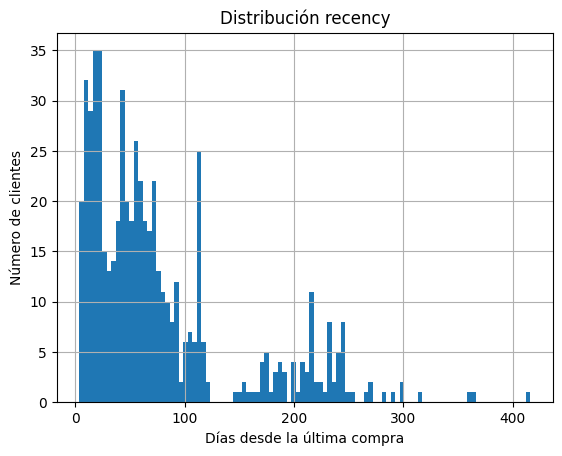

In [9]:
# grafica
recency['recency_days'].dropna().hist(bins=100)
plt.xlabel('Días desde la última compra')
plt.ylabel('Número de clientes')
plt.title('Distribución recency')
plt.show()

In [10]:
import numpy as np

df=recency.groupby('recency_days')['id_cliente'].count().reset_index().sort_values('recency_days', ascending=True)

rec = df['recency_days']

# estadísticas básicas
print('Descripción de datos de Recency: cantidad de días, la media de días, la desviación estándar, el rango de última compra, la mediana ...')
print(rec.describe(percentiles=[.25, .5, .75, .9]))

# percentiles concretos
for p in [50, 60,70 ,75, 80, 90, 95]:
    print(f"Día en que se alcanza el {p}%: ", np.percentile(rec, p), 'días')



Descripción de datos de Recency: cantidad de días, la media de días, la desviación estándar, el rango de última compra, la mediana ...
count         173.0
mean     121.381503
std       89.831911
min             4.0
25%            49.0
50%            94.0
75%           200.0
90%           242.8
max           416.0
Name: recency_days, dtype: Float64
Día en que se alcanza el 50%:  94.0 días
Día en que se alcanza el 60%:  114.2 días
Día en que se alcanza el 70%:  180.2 días
Día en que se alcanza el 75%:  200.0 días
Día en que se alcanza el 80%:  216.6 días
Día en que se alcanza el 90%:  242.8 días
Día en que se alcanza el 95%:  268.4 días


- La mitad de los clientes ha comprado hace 93 días o menos.
- El 25% de clientes ha comprado hace 48 días o menos. 
- El 80% de clientes ha comprado hace 216 días o menos.
- El 60% de clientes ha comprado hace 113 días o menos.
- De la gráfica: la distribución de recency está sesgada a la derecha. Significa que muchos clientes con recency media/baja lo cual es bueno porque implica clientes activos.
- También hay clientes que ya no han vuelto a comprar en más de 200, 300, 400 días. Probablemente las campañas para estos clientes no sean lo mejor, además de implicar inversión innecesaria.
- El **umbral** va a ser la media entre 60 a 70 %

In [48]:
umbral= round((113+180)/2)
umbral

146

### **Generar un nuevo df** con:
id_cliente - recency - frecuency - monetary

- Recency: hoy - ultima fecha de compra. Cuanto más bajo el valor mejor, significa que hay pocos días desde la última compra.
- Frecuency: nro total de compras en un periodo fijo(puede ser desde el inicio? el ecommerce funciona desde agosto 2024) tipo int
- Monetary: Suma total gastada por cliente. Tipo float


In [12]:
# id_cliente, recency, frecuency(nro_compras)
# clientes_ventas= pd.merge(customers, ventas, on='id_cliente', how='left')
# compras_cliente (frecuency)
# recency 
monetary = clientes_ventas.groupby('id_cliente')['precio_total'].sum().reset_index()

df_rfm= pd.merge(compras_cliente, recency,on='id_cliente', how='left') 
df_rfm = pd.merge(df_rfm,monetary, on='id_cliente', how='left')
df_rfm=df_rfm[['id_cliente', 'nro_compras','recency_days','precio_total']]
df_rfm.columns=['id_cliente', 'frecuency','recency','monetary']
df_rfm.head(5)

,id_cliente,frecuency,recency,monetary
0,15224213,57,77,43328593
1,13929252,20,6,8440338
2,13921724,5,93,1764750
3,14902887,5,289,2911899
4,17504525,3,5,918150


##  Creación del **target**
- Umbral definido churn= 156 días
- Asignación del target. Desde hoy hasta hace 156 días atrás, ¿ha realizado alguna compra?
  - Sí => target=0 (no churn)
  - No => target=1 (churn)

In [ ]:
df_rfm['target']= df_rfm['recency'].apply(lambda x: 0 if x<=umbral else 1)
df_rfm['target'].value_counts(normalize=True)

target
0    0.851027
1    0.148973
Name: proportion, dtype: float64

Como los datos estan desbalanceados, usar *class_weight='balanced'* en el modelo. Esta opción permite ajustar los pesos, y permite considerar los churners(target=1) con mayor importancia.

## Implementación del modelo (opcion1)

**Regresión logística**
Se utiliza para predecir valores binarios o que pertenezcan a dos categorias. Se denomina clasificación binaria. <br>
Ideal para tareas de clasificación.
- Ej: Probabilidad de morir o no.
- Consideración: 70 train, 30 test

¿Porqué no Regresión Lineal? Porque esta regresión se usa para predecir valores continuos.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# obtencion de parametros
x= df_rfm[['recency','frecuency','monetary']]
y= df_rfm['target']


# split test y train
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.3, random_state=16, stratify=y)

# pipeline, escala datos train internamente
# instancia del modelo
modelo_rlog= LogisticRegression(random_state=16, class_weight='balanced', solver='liblinear') # como si hay
pipe= make_pipeline(StandardScaler(),modelo_rlog)

# entrenamos y predecimos
modelo_rlog.fit(x_train, y_train)
y_pred= modelo_rlog.predict(x_test) # estos valores tienen que ser cercanos a y_test (a evaluar)

# en churn, mejor la probabilidad
y_prob= modelo_rlog.predict_proba(x_test)[:,1]

Evaluación

In [31]:
from sklearn.metrics import classification_report, roc_auc_score,confusion_matrix, roc_curve

confu= confusion_matrix(y_test, y_pred)
reporte= classification_report(y_test,y_pred) #exactitud, precision y recuperacion
roc_auc= roc_auc_score(y_test,y_prob)
fpr, tpr, _ = roc_curve(y_test,  y_prob) # para la grafica


Text(0.5, 427.9555555555555, 'Predicted label')

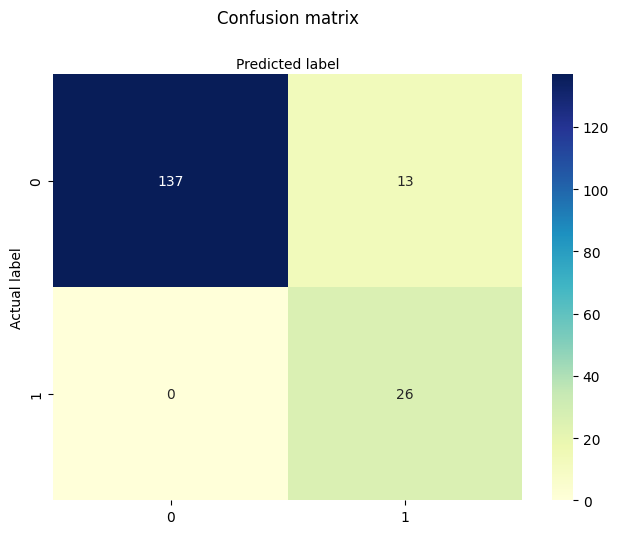

In [32]:
# matriz de confusion
# confu
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(confu), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


In [33]:
confu

array([[137,  13],
       [  0,  26]], dtype=int64)

Explicación Matrix de confusión: <br>
Indica que el modelo ha predicho correctamente 149 valores para target=0, y para aquellos no churn(1) 26. Ha predicho incorrectamente uno como que sí abandonaba pero en realidad no.

In [34]:
# Reporte para evaluar que tan bien lo ha realizado el modelo
print(reporte)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95       150
           1       0.67      1.00      0.80        26

    accuracy                           0.93       176
   macro avg       0.83      0.96      0.88       176
weighted avg       0.95      0.93      0.93       176



Explicación Reporte: <br>
La clasificación obtenida es del 99%, lo que se considera excelente. 


ROC AUC: 1.0


<function matplotlib.pyplot.show(close=None, block=None)>

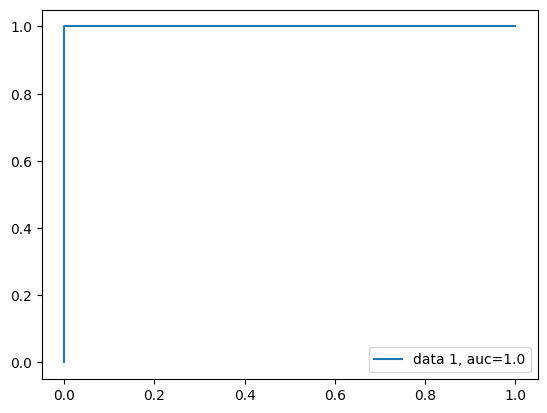

In [42]:
# curva ROC
print('ROC AUC:', roc_auc)

plt.plot(fpr,tpr,label="data 1, auc="+str(roc_auc))
plt.legend(loc=4)
plt.show

In [40]:
roc_auc

1.0

Explicación Curva Roc: <br>
Como la métrica de auc indica 1, entonces el clasificador es perfecto.

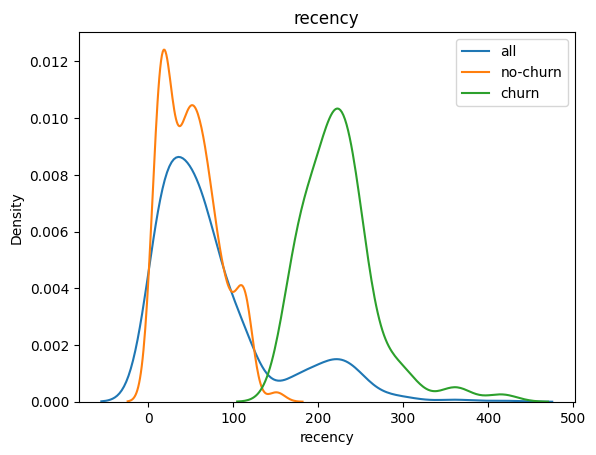

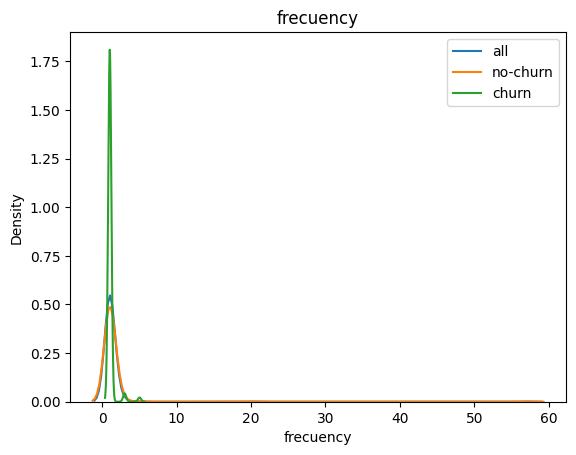

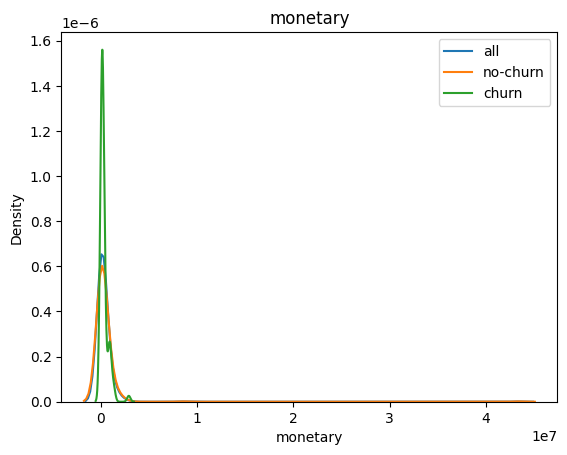

In [38]:
import seaborn as sns
for col in ['recency','frecuency','monetary']:
    sns.kdeplot(df_rfm[col].dropna(), label='all')
    sns.kdeplot(df_rfm[df_rfm['target']==0][col].dropna(), label='no-churn')
    sns.kdeplot(df_rfm[df_rfm['target']==1][col].dropna(), label='churn')
    plt.title(col); plt.legend(); plt.show()


In [39]:
baseline_pred = (df_rfm['recency'] > 156).astype(int)
from sklearn.metrics import roc_auc_score
print("Baseline AUC:", roc_auc_score(y_test, baseline_pred.loc[x_test.index]))


Baseline AUC: 1.0


In [43]:
coef = pipe.named_steps['logisticregression'].coef_[0]
features = ['recency','frecuency','monetary']
pd.Series(coef, index=features).sort_values()


frecuency   -1.434383e+00
monetary    -1.096930e-07
recency      2.938378e-02
dtype: float64

Se propone crear un nuevo dataset para el modelo debido a que la manera que ha sido creado este depende del recency.

## Creacion dataset para el modelo (opcion2)


In [ ]:
import pandas as pd
import numpy as np

# --- Parámetros ---
H_days = 156
H = pd.Timedelta(days=H_days)
snapshot_freq = '15D'   # cada 30 días -> más snapshots aumentan ejemplos (puedes bajar a '15D' si necesitas más)
min_history_days = 30  # no crear snapshots muy al inicio (opcional)

# --- Preprocesamiento transacciones ---
transactions = clientes_ventas.copy()

# convertir fechas
transactions['fecha_creacion'] = pd.to_datetime(transactions['fecha_creacion'])

# límites de tiempo para snapshots
min_date = transactions['fecha_creacion'].min()
max_date = transactions['fecha_creacion'].max()

snapshots = pd.date_range(
    start = min_date + pd.Timedelta(days=min_history_days),
    end   = max_date - H,
    freq  = snapshot_freq
)

# --- Generar dataset por snapshot ---
rows = []
for T0 in snapshots:
    # features calculadas usando solo datos <= T0
    trans_train = transactions[transactions['fecha_creacion'] <= T0]

    # agrega por cliente (ejemplos RFM + counts por ventanas)
    agg = trans_train.groupby('id_cliente').agg(
        recency_days = ('fecha_creacion', lambda x: (T0 - x.max()).days),
        frequency_all = ('id_orden', 'count'),
        # frequency_all= clientes_ventas.groupby('id_cliente')['id_orden'].count().reset_index().sort_values('id_orden', ascending=False)  
        monetary = ('precio_total', 'sum'),
        # frecuencias en ventanas cortas
        freq_30 = ('fecha_creacion', lambda x: x[x > T0 - pd.Timedelta(days=30)].count()),
        freq_90 = ('fecha_creacion', lambda x: x[x > T0 - pd.Timedelta(days=90)].count()),
    ).reset_index()


    # labels: compras en ventana (T0, T0+H]
    trans_future = transactions[(transactions['fecha_creacion'] > T0) & (transactions['fecha_creacion'] <= T0 + H)]
    future_flag = trans_future.groupby('id_cliente').size().rename('n_future').reset_index()

    agg = agg.merge(future_flag, on='id_cliente', how='left')
    agg['n_future'] = agg['n_future'].fillna(0).astype(int)
    # target: 1 = churn (NO compró en la ventana futura), 0 = no-churn (compró al menos 1 vez)
    agg['target'] = (agg['n_future'] == 0).astype(int)

    agg['T0'] = T0
    rows.append(agg)

dataset = pd.concat(rows, ignore_index=True)
# opcional: eliminar clientes con valores extremos o NANs
dataset = dataset.dropna(subset=['recency_days','frequency_all','monetary'])


In [71]:
dataset.head(5)

,id_cliente,recency_days,frequency_all,monetary,freq_30,freq_90,n_future,target,T0
0,13921590,26,1,19990,1,1,0,1,2024-08-31
1,13921724,26,1,19990,1,1,3,0,2024-08-31
2,13929252,30,1,99990,0,1,2,0,2024-08-31
3,13921590,41,1,19990,0,1,0,1,2024-09-15
4,13921724,41,1,19990,0,1,3,0,2024-09-15


## Modelo (opcion2)

In [67]:
# Split temporal por T0 (70% snapshots para train, 30% para test)
unique_T0 = np.sort(dataset['T0'].unique())
cut_idx = int(0.7 * len(unique_T0))
cut_date = unique_T0[cut_idx]

train_df = dataset[dataset['T0'] <= cut_date].copy()
test_df  = dataset[dataset['T0'] > cut_date].copy()

# Features y target
features = ['recency_days','frequency_all','freq_30','freq_90','monetary']
X_train = train_df[features]
y_train = train_df['target']
X_test  = test_df[features]
y_test  = test_df['target']

# pipeline (escalado + logistic)
pipe = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced',
                                                         solver='liblinear',
                                                         random_state=16))
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:,1]


Evaluacion

In [69]:
confu= confusion_matrix(y_test, y_pred)
reporte= classification_report(y_test,y_pred) #exactitud, precision y recuperacion
roc_auc= roc_auc_score(y_test,y_prob)
fpr, tpr, _ = roc_curve(y_test,  y_prob) # para la grafica

# Baseline: recency_days > H_days -> churn
baseline_pred = (test_df['recency_days'] > H_days).astype(int)

print("Baseline ROC AUC:", roc_auc_score(y_test, baseline_pred))
print("Model ROC AUC:", roc_auc)
print(reporte)
print(confu)


Baseline ROC AUC: 0.5179856115107914
Model ROC AUC: 0.9858513189448441
              precision    recall  f1-score   support

           0       0.37      1.00      0.54        15
           1       1.00      0.91      0.95       278

    accuracy                           0.91       293
   macro avg       0.68      0.95      0.74       293
weighted avg       0.97      0.91      0.93       293

[[ 15   0]
 [ 26 252]]


<function matplotlib.pyplot.show(close=None, block=None)>

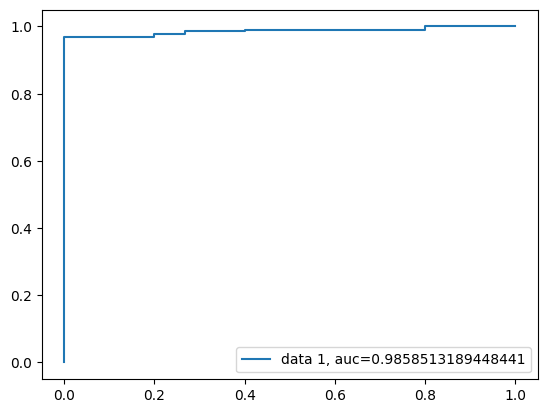

In [70]:
plt.plot(fpr,tpr,label="data 1, auc="+str(roc_auc))
plt.legend(loc=4)
plt.show

### Exportación del modelo

In [ ]:
import os

# Ruta actual donde está abierto el notebook
current_dir = os.getcwd()

# Retroceder una carpeta
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
ruta=os.path.join(parent_dir, 'streamlit_app',"modelo")
ruta


'c:\\Users\\Angelica\\Documents\\Temporal-Carrera\\PerceivoAI\\REPOS_GITHUB\\pipeline_perc\\streamlit_app\\modelo'

In [ ]:
import joblib


# Guardar modelo entrenado
joblib.dump(pipe, f"{ruta}/modelo_churn.pkl")

# Guardar features (opcional, pero ayuda a mantener consistencia)
joblib.dump(features, f"{ruta}/features.pkl")

['c:\\Users\\Angelica\\Documents\\Temporal-Carrera\\PerceivoAI\\REPOS_GITHUB\\pipeline_perc\\streamlit_app\\modelo/features.pkl']